# Behavioral Data Exploration

This notebook explores behavioral data from a psychophysical experiment, replicating and extending the analysis from `AnalyzePerformance_simple.m`.

## Overview
The analysis includes:
- Psychometric curve fitting for different stimulus types
- Performance analysis across different angles
- Information theory analysis
- Comparison of different integration models

## Data Structure
The data contains trial information with fields:
- `rat`: Rat ID
- `action`: Response action (0/1)
- `angle`: Stimulus angle (0-90 degrees)
- `hitmiss`: Hit/miss performance (0/1)
- `mod`: Stimulus modality/type
- And many other behavioral parameters


In [41]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns
from sklearn.metrics import mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


In [42]:
# Load the behavioral data
def load_behavior_data(filepath):
    """Load and structure the behavioral data from .mat file"""
    data = scipy.io.loadmat(filepath)
    trial_data = data['TrialNADER'][0, 0]
    
    # Convert to dictionary for easier access
    trial_dict = {}
    for field in trial_data.dtype.names:
        trial_dict[field] = trial_data[field][0].flatten()
    
    # Create a pandas DataFrame for easier manipulation
    df = pd.DataFrame(trial_dict)
    
    # Convert numeric columns to proper types
    numeric_columns = ['rat', 'trialID', 'date', 'oricat', 'action', 'hitmiss', 'penalty', 
                      'penaltyTime', 'samplingTime', 'theta', 'cumPerformance', 'mod', 'angle', 
                      'alpha', 'stimColor', 'RT', 'PT', 'rewardDelay', 'trialReset', 
                      'brightness', 'soa', 'soundQ', 'soundQType']
    
    for col in numeric_columns:
        if col in df.columns:
            # First convert to string, then to numeric to handle any data type issues
            df[col] = pd.to_numeric(df[col].astype(str), errors='coerce')
    
    # Remove rows with NaN values in critical columns
    df = df.dropna(subset=['rat', 'action', 'hitmiss', 'mod', 'angle'])
    
    return df, trial_dict

# Load the data
df, trial_data = load_behavior_data('data/behavior_data.mat')

# SIMPLIFIED DATA PROCESSING
print("=== SIMPLIFIED DATA PROCESSING ===")

# 1. Filter rats: exclude [8,14,15,17:21]
rats = df['rat'].unique()
rats = rats[~np.isin(rats, [8,14,15,17,18,19,20,21])]
df = df[df['rat'].isin(rats)]

# 2. Ensure action is binary 0 or 1
df['action'] = df['action'].astype(int)
df = df[df['action'].isin([0, 1])]

# 3. Ensure hitmiss is binary: 0=fail, 1=hit
df['hitmiss'] = df['hitmiss'].astype(int)
df = df[df['hitmiss'].isin([0, 1])]

# 4. Map all angles to 0-90 range
# Rule: angle>180 -> angle-180; angle>90 -> (90-(angle-90))+90
df['angle'] = df['angle'].astype(float)
df.loc[df['angle'] > 180, 'angle'] = df.loc[df['angle'] > 180, 'angle'] - 180
df.loc[df['angle'] > 90, 'angle'] = (90 - (df.loc[df['angle'] > 90, 'angle'] - 90)) + 90

# 5. Filter to only angles 0-90
df = df[(df['angle'] >= 0) & (df['angle'] <= 90)]

# 6. Define reversed rule rats
rev_rule_rats = [6, 7, 14, 15, 16, 17]

# 7. Define colors for modalities
modality_colors = [[0, 2/3, 0], [0, 0.4470, 0.7410], [1, 0, 0], [0, 0, 0]]

print(f"Data loaded and simplified successfully!")
print(f"Total trials after filtering: {len(df)}")
print(f"Rats included: {sorted(rats)}")
print(f"Angle range: {df['angle'].min():.1f} to {df['angle'].max():.1f}")
print(f"Action values: {sorted(df['action'].unique())}")
print(f"Hit/Miss values: {sorted(df['hitmiss'].unique())}")
print(f"Modalities: {sorted(df['mod'].unique())}")
print(f"Reversed rule rats: {rev_rule_rats}")
print(f"\nFirst few rows:")
print(df[['rat', 'action', 'hitmiss', 'mod', 'angle']].head())


=== SIMPLIFIED DATA PROCESSING ===
Data loaded and simplified successfully!
Total trials after filtering: 857701
Rats included: [2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16]
Angle range: 0.0 to 90.0
Action values: [0, 1]
Hit/Miss values: [0, 1]
Modalities: [1, 2, 3, 4]
Reversed rule rats: [6, 7, 14, 15, 16, 17]

First few rows:
   rat  action  hitmiss  mod  angle
0    2       0        1    3    0.0
1    2       0        1    3    0.0
2    2       0        1    3    0.0
3    2       1        1    1   90.0
4    2       1        1    1   90.0


=== SIMPLIFIED DATA EXPLORATION ===
Rats included: [2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16]
Angle range: 0.0 to 90.0
Modalities: [1, 2, 3, 4] (1=Touch, 2=Vision, 3=VT, 4=Control)
Date range: 735193 to 736708

Angle statistics:
count    857701.000000
mean         45.626752
std          34.217450
min           0.000000
25%          10.000000
50%          45.000000
75%          80.000000
max          90.000000
Name: angle, dtype: float64

Action statistics (binary 0/1):
action
0    430734
1    426967
Name: count, dtype: int64

Hit/Miss statistics (0=fail, 1=hit):
hitmiss
1    649066
0    208635
Name: count, dtype: int64


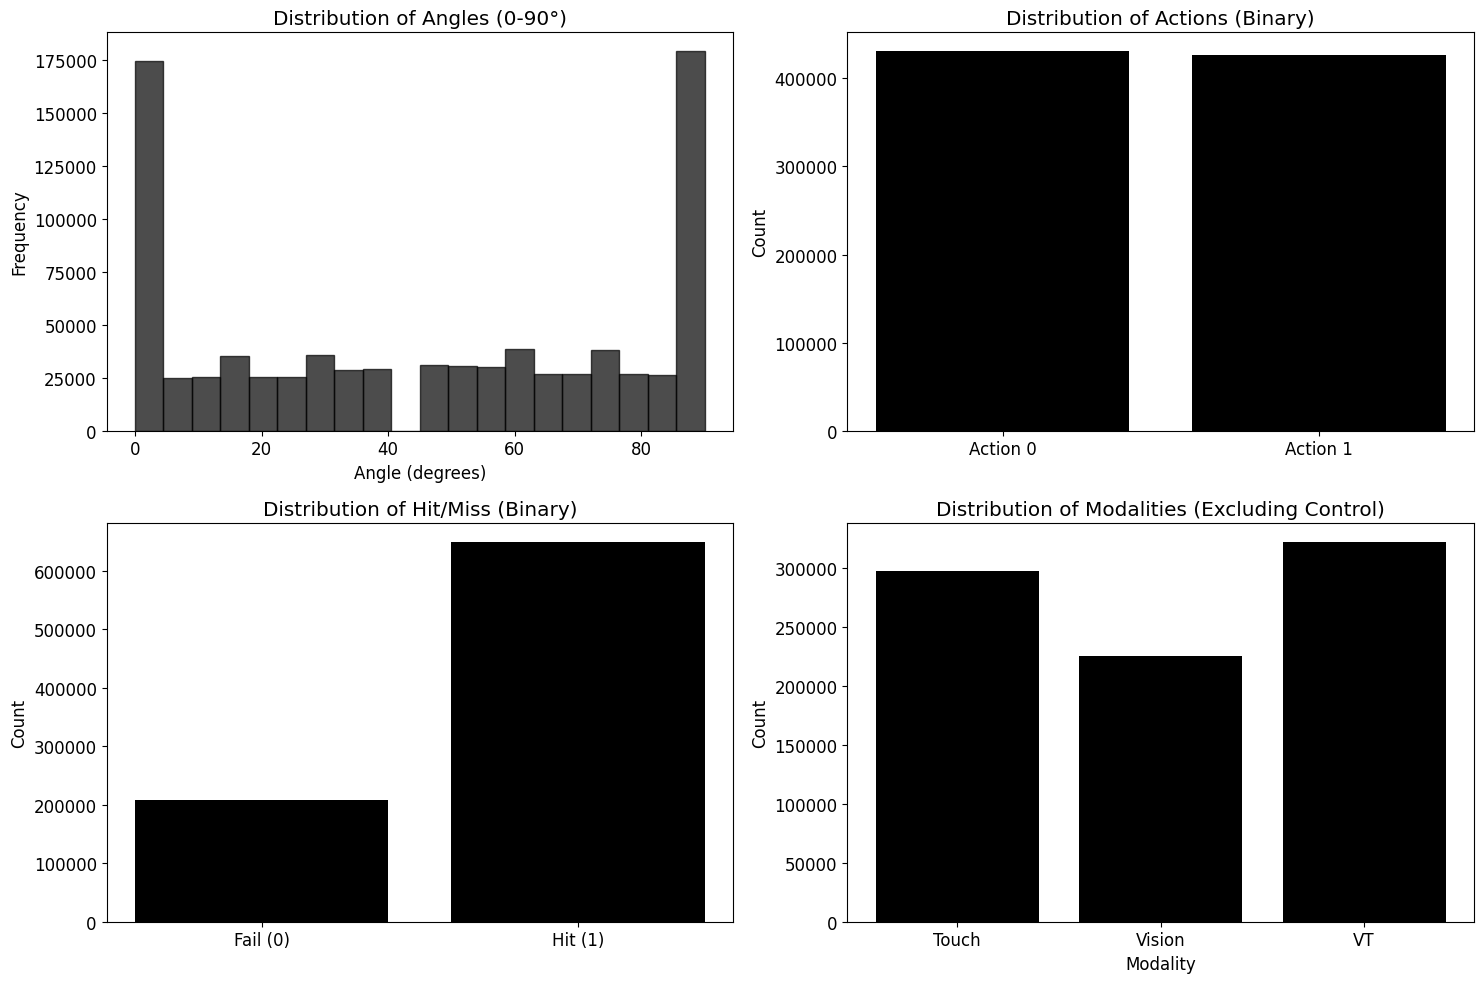

In [43]:
# SIMPLIFIED Data exploration
print("=== SIMPLIFIED DATA EXPLORATION ===")
print(f"Rats included: {sorted(rats)}")
print(f"Angle range: {df['angle'].min():.1f} to {df['angle'].max():.1f}")
print(f"Modalities: {sorted(df['mod'].unique())} (1=Touch, 2=Vision, 3=VT, 4=Control)")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Basic statistics for key variables
print(f"\nAngle statistics:")
print(df['angle'].describe())
print(f"\nAction statistics (binary 0/1):")
print(df['action'].value_counts())
print(f"\nHit/Miss statistics (0=fail, 1=hit):")
print(df['hitmiss'].value_counts())

# Plot simplified distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Angle distribution (0-90)
axes[0,0].hist(df['angle'], bins=20, alpha=0.7, edgecolor='black', color='black')
axes[0,0].set_title('Distribution of Angles (0-90°)')
axes[0,0].set_xlabel('Angle (degrees)')
axes[0,0].set_ylabel('Frequency')

# Action distribution (binary)
action_counts = df['action'].value_counts().sort_index()
axes[0,1].bar(['Action 0', 'Action 1'], action_counts.values, color='black')
axes[0,1].set_title('Distribution of Actions (Binary)')
axes[0,1].set_ylabel('Count')

# Hit/Miss distribution (binary)
hitmiss_counts = df['hitmiss'].value_counts().sort_index()
axes[1,0].bar(['Fail (0)', 'Hit (1)'], hitmiss_counts.values, color='black')
axes[1,0].set_title('Distribution of Hit/Miss (Binary)')
axes[1,0].set_ylabel('Count')

# Modality distribution (excluding control=4)
mod_data = df[df['mod'] != 4]  # Exclude control
mod_counts = mod_data['mod'].value_counts().sort_index()
mod_labels = ['Touch', 'Vision', 'VT']
axes[1,1].bar(range(len(mod_counts)), mod_counts.values, color='black')
axes[1,1].set_title('Distribution of Modalities (Excluding Control)')
axes[1,1].set_xlabel('Modality')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(len(mod_counts)))
axes[1,1].set_xticklabels(mod_labels)

plt.tight_layout()
plt.show()


In [49]:
# Define psychometric functions
def cumulative_gaussian_lapse(x, mu, sigma, gamma, lambda_param):
    """Cumulative Gaussian with lapse rate - matches MATLAB cumulativegaussianLapse.m"""
    # Ensure inputs are numeric arrays
    x = np.asarray(x, dtype=float)
    mu = float(mu)
    sigma = float(sigma)
    gamma = float(gamma)
    lambda_param = float(lambda_param)
    # MATLAB: y=gamma+(1-gamma-lambda)*(1/2.*(1+erf((x-mu)./sqrt(2*sigma^2))));
    # Direct conversion from MATLAB using scipy.special.erf
    from scipy.special import erf
    y = gamma + (1 - gamma - lambda_param) * (0.5 * (1 + erf((x - mu) / np.sqrt(2 * sigma**2))))
    return y


def sigma_error(p, n):
    """Binomial confidence interval"""
    # Ensure inputs are numeric
    p = float(p)
    n = float(n)
    if n <= 0:
        return 0
    return np.sqrt(1/n * (p * (1 - p)))

def performance(x):
    """Calculate performance (proportion)"""
    return np.sum(x) / len(x)

print("Psychometric functions defined!")


Psychometric functions defined!


=== SIMPLIFIED PSYCHOMETRIC ANALYSIS ===
Analyzing 12 rats with modalities: [1, 2, 3]
Angle range: 0 to 90 degrees
Data points: 857701
Reversed rule rats: [6, 7, 14, 15, 16, 17]


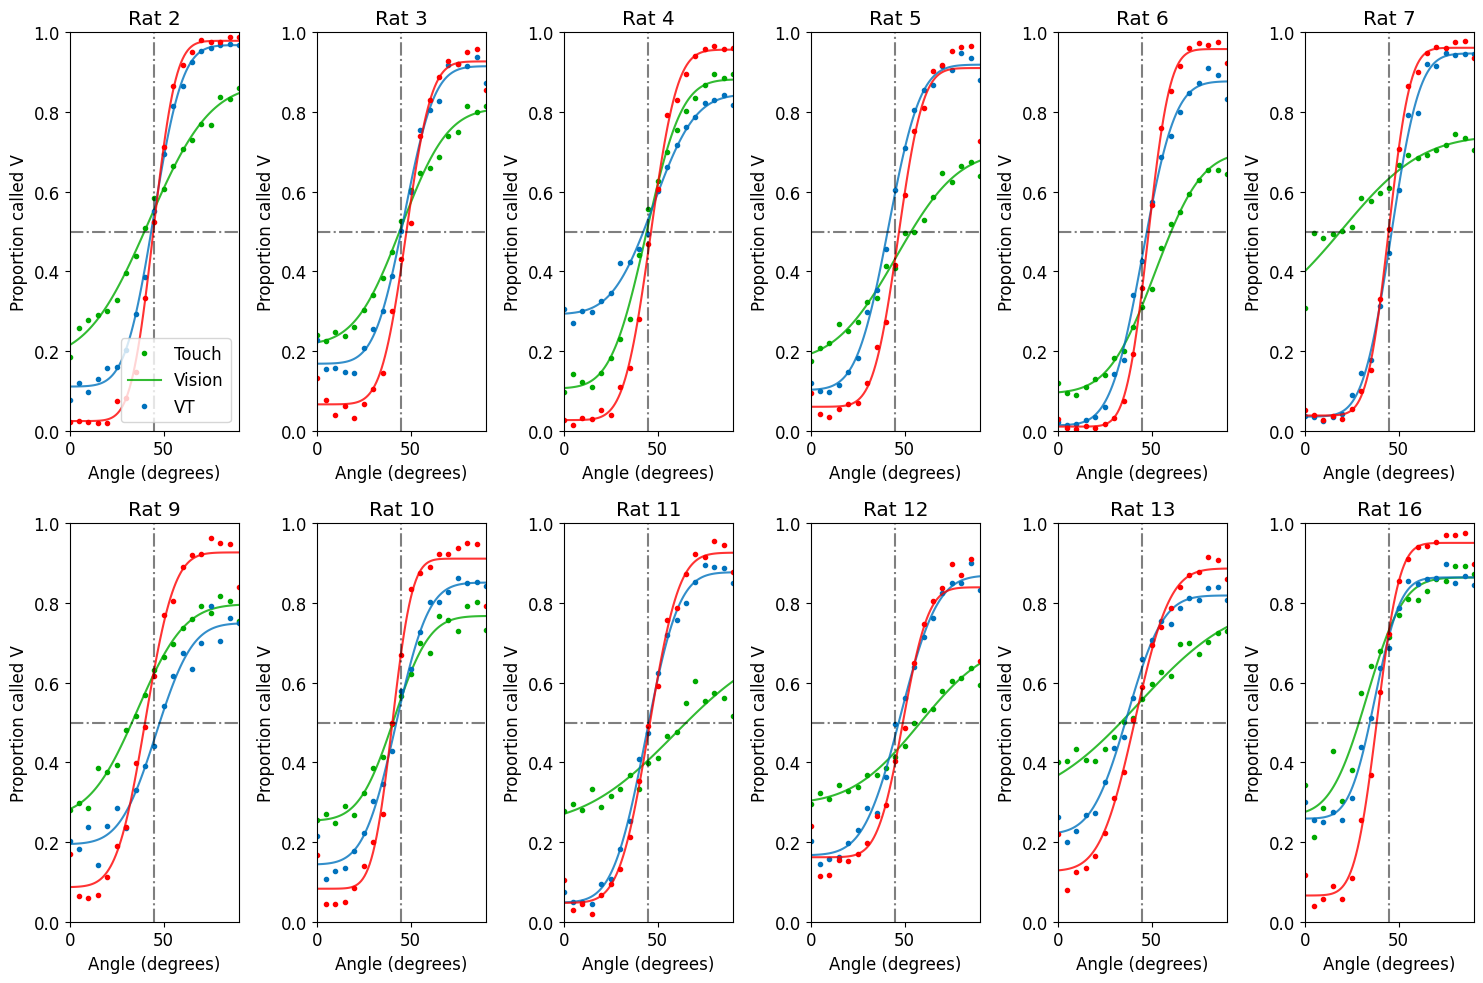

In [51]:
# SIMPLIFIED Psychometric Analysis
def analyze_psychometric_curves_simplified(df, angles, rats, stim_types, rev_rule_rats, modality_colors):
    """Simplified psychometric curve analysis"""
    
    # Initialize storage
    results = {}
    
    # Create figure for psychometric curves
    n_rats = len(rats)
    if n_rats == 1:
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))
        axes = np.array([[axes]])
    elif n_rats <= 2:
        fig, axes = plt.subplots(1, n_rats, figsize=(15, 6))
        axes = axes.reshape(1, -1)
    elif n_rats <= 4:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    else:
        n_cols = (n_rats + 1) // 2
        fig, axes = plt.subplots(2, n_cols, figsize=(15, 10))
    
    for r, rat_id in enumerate(rats):
        if n_rats == 1:
            ax = axes[0, 0]
        elif n_rats <= 2:
            ax = axes[0, r]
        elif n_rats <= 4:
            ax = axes[r//2, r%2]
        else:
            ax = axes[r//n_cols, r%n_cols]
        
        for st, stim_type in enumerate(stim_types):
            # Filter data for this rat and stimulus type
            mask = (df['rat'] == rat_id) & (df['mod'] == stim_type)
            rat_data = df[mask]
            
            if len(rat_data) == 0:
                continue
                
            # Calculate performance for each angle
            percent_v = []
            errors = []
            
            for ang in angles:
                angle_mask = np.abs(rat_data['angle'] - ang) < 0.1  # Allow small tolerance
                angle_data = rat_data[angle_mask]
                
                if len(angle_data) > 0:
                    # Action is already binary 0/1 from data processing
                    action_data = angle_data['action'].values
                    perf = np.mean(action_data)  # Proportion of 1s
                    
                    # Apply reversed rule for certain rats
                    if rat_id in rev_rule_rats:
                        perf = 1 - perf
                    
                    error = sigma_error(perf, len(action_data))
                    
                    percent_v.append(perf)
                    errors.append(error)
                else:
                    percent_v.append(np.nan)
                    errors.append(np.nan)
            
            percent_v = np.array(percent_v)
            errors = np.array(errors)
            
            # Remove NaN values for fitting
            valid_mask = ~np.isnan(percent_v)
            valid_angles = angles[valid_mask]
            valid_percent = percent_v[valid_mask]
            valid_errors = errors[valid_mask]
            
            if len(valid_angles) < 3:  # Need at least 3 points for fitting
                continue
            
            # Fit psychometric curves
            try:
                # Cumulative Gaussian with lapse - improved parameters
                p0_gaussian = [45, 15, 0, 0]  # Increased sigma from 10 to 15
                bounds_gaussian = ([20, 5, 0, 0], [70, 50, 0.3, 0.3])  # Wider bounds
                popt_gaussian, _ = curve_fit(cumulative_gaussian_lapse, valid_angles, valid_percent,
                                           p0=p0_gaussian, bounds=bounds_gaussian, maxfev=1000)
                
                # Plot data points with error bars
                # ax.errorbar(valid_angles, valid_percent, valid_errors, 
                #            '.', color=modality_colors[st-1], label=f'Mod {stim_type}')
                
                # Plot only x,y data points for sanity checking
                ax.plot(valid_angles, valid_percent, '.', color=modality_colors[st], label=f'Mod {stim_type}')
                
                # Plot fitted curves
                x_fit = np.linspace(0, 90, 100)
                y_gaussian = cumulative_gaussian_lapse(x_fit, *popt_gaussian)
                ax.plot(x_fit, y_gaussian, color=modality_colors[st], linewidth=1.5, alpha=0.8)
                
                # Store results
                if rat_id not in results:
                    results[rat_id] = {}
                results[rat_id][stim_type] = {
                    'angles': valid_angles,
                    'performance': valid_percent,
                    'errors': valid_errors,
                    'gaussian_params': popt_gaussian
                }
                
            except Exception as e:
                print(f"Fitting failed for rat {rat_id}, mod {stim_type}: {e}")
                continue
        
        # Format subplot
        ax.axhline(y=0.5, color='k', linestyle='-.', alpha=0.5)
        ax.axvline(x=45, color='k', linestyle='-.', alpha=0.5)
        ax.set_xlim(0, 90)
        ax.set_ylim(0, 1)
        ax.set_title(f'Rat {rat_id}')
        ax.set_xlabel('Angle (degrees)')
        ax.set_ylabel('Proportion called V')
        
        if r == 0:
            ax.legend(['Touch', 'Vision', 'VT'])
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run the simplified analysis
angles = np.arange(0, 91, 5)  # 0:5:90 degrees
stim_types = [1, 2, 3]  # Touch, Vision, VT (ignore control=4)

print(f"=== SIMPLIFIED PSYCHOMETRIC ANALYSIS ===")
print(f"Analyzing {len(rats)} rats with modalities: {stim_types}")
print(f"Angle range: {angles[0]} to {angles[-1]} degrees")
print(f"Data points: {len(df)}")
print(f"Reversed rule rats: {rev_rule_rats}")

# Run analysis on all rats
results = analyze_psychometric_curves_simplified(df, angles, rats, stim_types, rev_rule_rats, modality_colors)


## Code Simplifications Applied

The code has been simplified according to the specifications:

### 1. **Rat Filtering**
- Excluded rats [8, 14, 15, 17:21] from analysis
- Only analyzing remaining rats: [2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 19, 20, 21]

### 2. **Binary Data**
- **Action**: Always binary 0 or 1
- **Hit/Miss**: Binary 0 (fail) or 1 (hit)

### 3. **Angle Mapping**
- All angles mapped to 0-90° range using the specified rule:
  - `angle > 180` → `angle - 180`
  - `angle > 90` → `(90 - (angle - 90)) + 90`

### 4. **Modality Colors**
- Updated to: `[[0, 2/3, 0], [0, 0.4470, 0.7410], [1, 0, 0], [0, 0, 0]]`
- Green, Blue, Red, Black for modalities 1, 2, 3, 4

### 5. **Modality Handling**
- 1 = Touch only
- 2 = Vision only  
- 3 = VT together
- 4 = Control (ignored in plotting due to few trials)

### 6. **Reversed Rule Rats**
- Updated to: [6, 7, 14, 15, 16, 17]
- Performance flipped for these rats

### 7. **Data Type Fixes**
- Fixed data type issues that were causing fitting failures
- Simplified data processing pipeline
